In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

Path to dataset files: /Users/diy-101/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [244]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import sklearn as sk
import os
import warnings
import scipy as sci
warnings.filterwarnings("ignore")

In [245]:
data = pd.read_csv(path+"/Teen_Mental_Health_Dataset.csv")

# EDA

In [246]:
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [247]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [248]:
len(data)

1200

In [249]:
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [250]:
target_name = "depression_label"
target = data[target_name]
features = data.drop(columns=[target_name])
num_features = features.select_dtypes(exclude=["object"])
cat_features = features.select_dtypes(include=["object"])

target.unique()

array([0, 1])

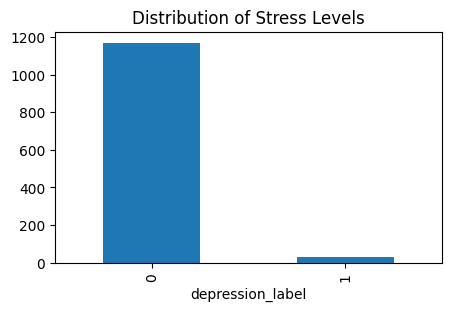

In [251]:
plt.figure(figsize=(5, 3))

target.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Stress Levels")
plt.show()

In [252]:
num_features

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2
...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,3,4,4
1196,16,2.3,8.0,1.9,2.12,0.4,7,4,4
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,1
1198,15,3.9,8.5,2.1,3.19,0.6,7,9,9


<Axes: >

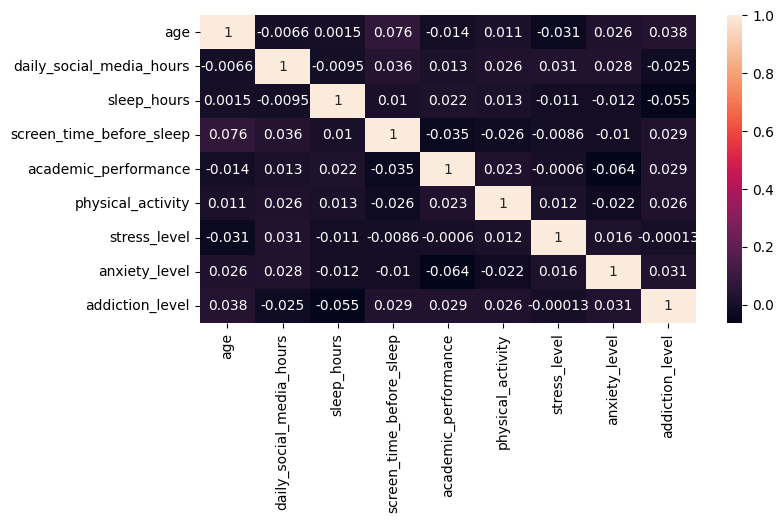

In [253]:
plt.figure(figsize=(8, 4))
sns.heatmap(data=num_features.corr(), annot=True)

In [254]:
rs, ps = sci.stats.spearmanr(num_features["anxiety_level"], target)
rp, pp = sci.stats.pearsonr(num_features["anxiety_level"], target)
rk, pk = sci.stats.kendalltau(num_features["anxiety_level"], target)

print(f"Spearman correlation: {rs:.5f}, p-value: {ps}")
print(f"Pearson correlation: {rp:.5f}, p-value: {pp}")
print(f"Kendall's tau: {rk:.5f}, p-value: {pk}")

Spearman correlation: 0.16982, p-value: 3.2229397734579256e-09
Pearson correlation: 0.16957, p-value: 3.4071074421533778e-09
Kendall's tau: 0.14548, p-value: 4.0915480082244395e-09


In [255]:
cat_features

,gender,platform_usage,social_interaction_level
0,male,Instagram,low
1,female,TikTok,high
2,female,Instagram,high
3,male,TikTok,medium
4,female,Both,medium
...,...,...,...
1195,female,Instagram,low
1196,male,Both,high
1197,female,Both,high
1198,male,Both,high


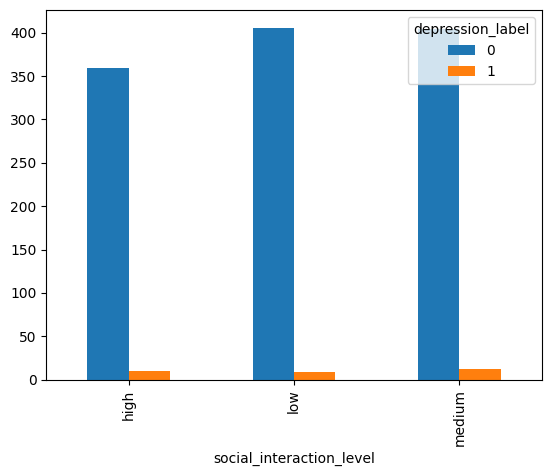

In [256]:
cross = pd.crosstab(cat_features['social_interaction_level'], target)
cross.plot(kind="bar")
plt.show()

In [257]:
chi2, pvalue, dof, expected = sci.stats.chi2_contingency(cross)
print(f"Chi-squared statistic: {chi2:.5f}, p-value: {pvalue:.5f}")

Chi-squared statistic: 0.45712, p-value: 0.79568


In [258]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OrdinalEncoder

cat_features_encoded = OrdinalEncoder().fit_transform(cat_features)
chi2, p_values = chi2(cat_features_encoded, target)
p_values, cat_features.columns.values

df = pd.DataFrame(index=cat_features.columns.values, data={
    "p_value": p_values
}).sort_values("p_value")
df.T

,platform_usage,gender,social_interaction_level
p_value,0.608989,0.631384,0.88844


In [259]:
num_features.corrwith(target).sort_values(ascending=False)

daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
dtype: float64

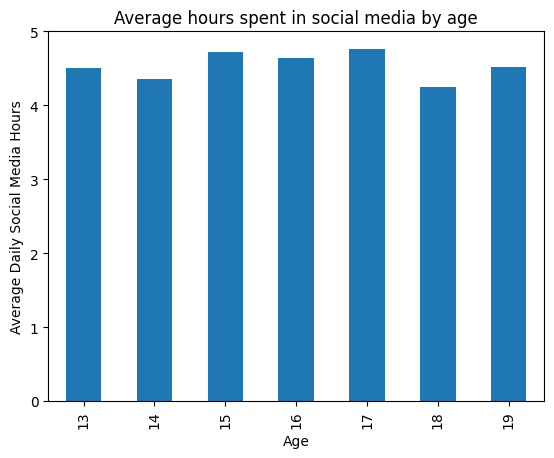

In [260]:
num_features.groupby("age")['daily_social_media_hours'].mean().plot(kind="bar")
plt.title("Average hours spent in social media by age")
plt.xlabel("Age")
plt.ylabel("Average Daily Social Media Hours")
plt.show()

<Axes: xlabel='depression_label'>

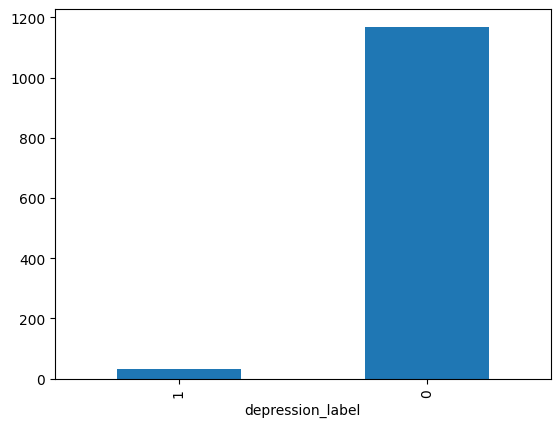

In [261]:
target.value_counts().sort_values().plot(kind="bar")

# Data preparation

In [262]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

ohe = OrdinalEncoder()
cat_features_encoded = pd.DataFrame(ohe.fit_transform(cat_features), columns=ohe.get_feature_names_out(cat_features.columns))
all_features = pd.concat([num_features, cat_features_encoded], axis=1)
all_features.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender,platform_usage,social_interaction_level
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1.0,1.0,1.0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0.0,2.0,0.0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0.0,1.0,0.0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1.0,2.0,2.0
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0.0,0.0,2.0


In [263]:
X_train, X_test, y_train, y_test = train_test_split(all_features, target, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((960, 12), (240, 12), (960,), (240,))

In [264]:
X_train_resampled, y_train_resampled = SMOTE(random_state=42, k_neighbors=2).fit_resample(X_train, y_train)
X_train_resampled.shape, y_train_resampled.shape

((1870, 12), (1870,))

<Axes: xlabel='depression_label'>

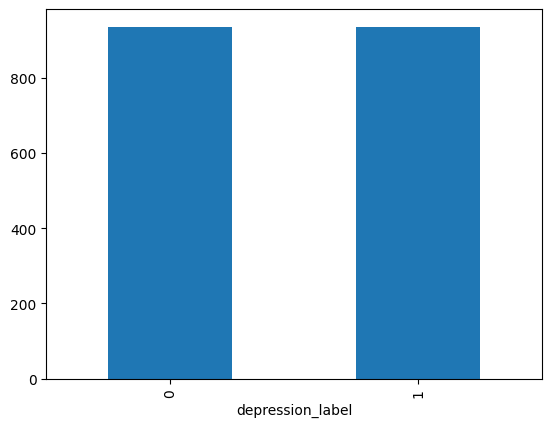

In [265]:
y_train_resampled.value_counts().plot(kind="bar")

# Model building

In [266]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [267]:
model = GradientBoostingClassifier(
                              max_depth=10,
                              random_state=42)
model.fit(X_train_resampled, y_train_resampled)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

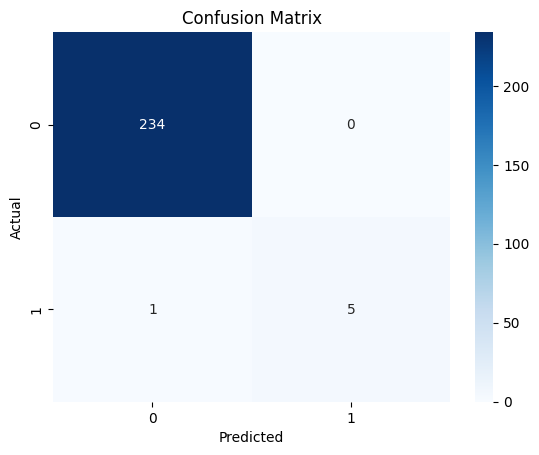

In [268]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

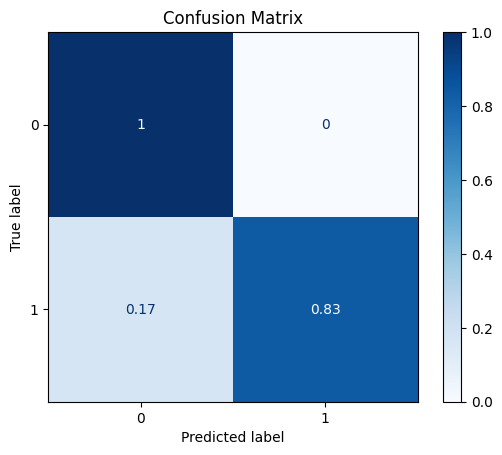

In [269]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", normalize="true")
plt.title("Confusion Matrix")
plt.show()

In [270]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      0.83      0.91         6

    accuracy                           1.00       240
   macro avg       1.00      0.92      0.95       240
weighted avg       1.00      1.00      1.00       240



<Axes: >

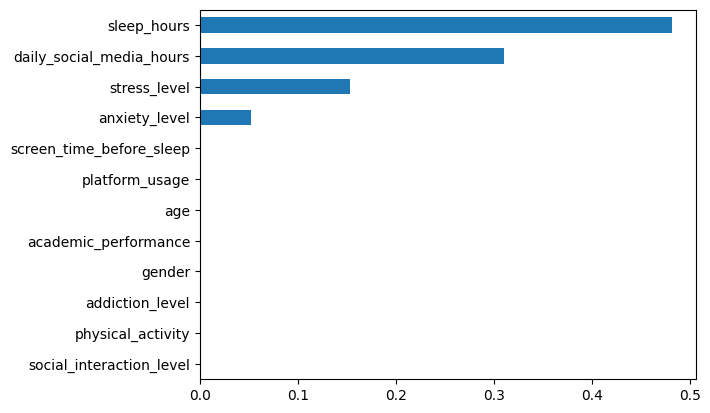

In [271]:
pd.Series(model.feature_importances_, index=all_features.columns).sort_values(ascending=True).plot(kind="barh")